# MDM2 pIC50 Applicability-Domain Analysis

This notebook evaluates the similarity-based applicability domain of the
previously trained MDM2 ExtraTrees pIC50 model for:

- REINVENT Generation 1 candidates
- REINVENT Generation 2 candidates
- DiffSBDD-generated candidates

The analysis uses maximum Morgan/Tanimoto similarity to the original MDM2
QSAR training set. An empirical applicability-domain threshold is derived
from the nearest-training similarity distributions of the held-out validation
and test sets.

The purpose of this analysis is to determine whether predicted pIC50 values
for generated molecules are supported by chemical space represented in the
original QSAR training dataset or should instead be interpreted as
extrapolative predictions.

In [1]:
from pathlib import Path
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

ROOT = Path("/Users/maryta/Downloads/mdm2_Reinvent_4_final")

SPLIT_CSV = (
    ROOT
    / "data/padel/mdm2_pic50_1D_2D/output/"
    / "extratrees_scaffold_model/"
    / "mdm2_scaffold_split_assignments.csv"
)

split_df = pd.read_csv(SPLIT_CSV)

print("Shape:", split_df.shape)
print("\nSplit counts:")
print(split_df["split"].value_counts())

display(split_df.head())

Shape: (4048, 7)

Split counts:
split
train         2834
validation     607
test           607
Name: count, dtype: int64


,dataset_row_index,Name,padel_molecule_id,standardized_smiles,pIC50,scaffold,split
0,0,MDM2_000000,MDM2_000000,C#CCC1CN(c2nc3nc(C(=O)O)nc(N[C@H](C)C4CCC4)c3n...,7.465466,c1ccc(Cn2c(N3CCOCC3)nc3ncnc(NCC4CCC4)c32)cc1,train
1,1,MDM2_000001,MDM2_000001,C#Cc1ccc(CN2C(=O)c3cc(C(C)(C)O)cc(F)c3[C@]2(OC...,8.116422,O=C1c2ccccc2C(OCC2CC2)(c2ccccc2)N1Cc1ccccc1,train
2,2,MDM2_000002,MDM2_000002,C#Cc1ccc(CN2C(=O)c3cc(C(C)(C)O)ccc3[C@]2(OCC2(...,7.958607,O=C1c2ccccc2C(OCC2CC2)(c2ccccc2)N1Cc1ccccc1,train
3,3,MDM2_000003,MDM2_000003,C#Cc1ccc(CN2C(=O)c3cc(C(C)(O)CO)cc(F)c3[C@]2(O...,8.283997,O=C1c2ccccc2C(OCC2CC2)(c2ccccc2)N1Cc1ccccc1,train
4,4,MDM2_000004,MDM2_000004,C#Cc1ccc(CN2C(=O)c3cc([C@@](C)(O)CO)cc(F)c3[C@...,8.283997,O=C1c2ccccc2C(OCC2CC2)(c2ccccc2)N1Cc1ccccc1,train


### AD.2 — Build Morgan Fingerprints and Derive the Empirical AD Threshold

In [2]:
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
import numpy as np
import pandas as pd

# Same Morgan settings used in the pIC50 model
fp_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048,
    includeChirality=True
)

# Split datasets
train_df = split_df[split_df["split"] == "train"].copy()
val_df = split_df[split_df["split"] == "validation"].copy()
test_df = split_df[split_df["split"] == "test"].copy()

def make_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return fp_gen.GetFingerprint(mol) if mol is not None else None

# Build training fingerprints
train_fps = [
    make_fp(smi)
    for smi in train_df["standardized_smiles"]
]

# Remove any unexpected failures
train_fps = [fp for fp in train_fps if fp is not None]

def nearest_train_similarity(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.nan

    fp = fp_gen.GetFingerprint(mol)

    sims = DataStructs.BulkTanimotoSimilarity(
        fp,
        train_fps
    )

    return max(sims)

# Calculate nearest-training similarity
val_df["Nearest_Train_Similarity"] = (
    val_df["standardized_smiles"]
    .apply(nearest_train_similarity)
)

test_df["Nearest_Train_Similarity"] = (
    test_df["standardized_smiles"]
    .apply(nearest_train_similarity)
)

# Empirical threshold:
# lower 10th percentile of combined held-out similarity distribution
heldout_similarity = pd.concat(
    [
        val_df["Nearest_Train_Similarity"],
        test_df["Nearest_Train_Similarity"]
    ],
    ignore_index=True
).dropna()

AD_THRESHOLD = heldout_similarity.quantile(0.10)

print("Validation median:",
      val_df["Nearest_Train_Similarity"].median())

print("Test median:",
      test_df["Nearest_Train_Similarity"].median())

print("\nEmpirical AD threshold (10th percentile):")
print(AD_THRESHOLD)

Validation median: 0.7816091954022989
Test median: 0.7721518987341772

Empirical AD threshold (10th percentile):
0.6459358288770054


### AD.3 — Evaluate REINVENT Generation 1 Against the pIC50 Applicability Domain

In [4]:
GEN1_CSV = (
    ROOT
    / "outputs/reinvent/mdm2_logs_qed_similarity_pilot/"
    / "generation1_full_with_admet.csv"
)

gen1_df = pd.read_csv(GEN1_CSV)

print("Shape:", gen1_df.shape)
print("\nColumns:")
print(gen1_df.columns.tolist())

display(gen1_df.head())

Shape: (870, 7)

Columns:
['SMILES', 'Bioavailability_Ma', 'hERG', 'DILI', 'Pgp_Broccatelli', 'CYP3A4_Veith', 'generation']


,SMILES,Bioavailability_Ma,hERG,DILI,Pgp_Broccatelli,CYP3A4_Veith,generation
0,COc1ccc(OCCOCCOCCOCCOCCON)c(C2=N[C@@H](c3ccc(C...,0.735462,0.966397,0.890423,0.994969,0.988147,Gen1
1,COc1ccc(C2=N[C@@H](c3ccc(Cl)cc3)[C@@H](c3ccc(C...,0.778472,0.985243,0.866822,0.972879,0.970157,Gen1
2,COc1ccc(OC[CH]CN2CCNCC2)c(C2=N[C@@H](c3ccc(Cl)...,0.757485,0.980198,0.702832,0.916737,0.862852,Gen1
3,COc1ccc(C2=N[C@@H](c3ccc(Cl)cc3)[C@@H](c3ccc(C...,0.832231,0.972059,0.905925,0.984196,0.942015,Gen1
4,COc1ccc(C2=N[C@@H](c3ccc(Cl)cc3)[C@@H](c3ccc(C...,0.899102,0.942976,0.932696,0.967936,0.828944,Gen1


### AD.4 — Compute REINVENT Generation 1 Nearest-Training Similarity

In [5]:
gen1_df["Nearest_Train_Similarity"] = (
    gen1_df["SMILES"]
    .apply(nearest_train_similarity)
)

print("Gen1 molecules:", len(gen1_df))
print("Valid similarity values:",
      gen1_df["Nearest_Train_Similarity"].notna().sum())

print("\nGen1 similarity summary:")
print(
    gen1_df["Nearest_Train_Similarity"]
    .describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

gen1_df["AD_Supported"] = (
    gen1_df["Nearest_Train_Similarity"] >= AD_THRESHOLD
)

print("\nAD threshold:", AD_THRESHOLD)

print("Gen1 above threshold:",
      int(gen1_df["AD_Supported"].sum()))

print("Gen1 below threshold:",
      int((~gen1_df["AD_Supported"]).sum()))

print(
    "Percent supported:",
    100 * gen1_df["AD_Supported"].mean()
)

Gen1 molecules: 870
Valid similarity values: 870

Gen1 similarity summary:
count    870.000000
mean       0.440254
std        0.063733
min        0.256098
10%        0.359465
25%        0.395349
50%        0.443182
75%        0.479834
90%        0.519037
95%        0.539018
max        0.690141
Name: Nearest_Train_Similarity, dtype: float64

AD threshold: 0.6459358288770054
Gen1 above threshold: 3
Gen1 below threshold: 867
Percent supported: 0.3448275862068966


### AD.5 — Evaluate REINVENT Generation 2 Against the pIC50 Applicability Domain

In [6]:
GEN2_CSV = (
    ROOT
    / "outputs/reinvent/mdm2_generation2_100step_gated/"
    / "sampling/generation2_top100_final_candidates.csv"
)

gen2_df = pd.read_csv(GEN2_CSV)

print("Shape:", gen2_df.shape)
print("\nColumns:")
print(gen2_df.columns.tolist())

display(gen2_df.head())

Shape: (100, 26)

Columns:
['rank', 'source_temperature', 'source_file', 'SMILES', 'canonical_smiles', 'predicted_pIC50', 'QED', 'similarity_to_Nutlin3a', 'Solubility_AqSolDB', 'Bioavailability_Ma', 'hERG', 'DILI', 'Pgp_Broccatelli', 'CYP3A4_Veith', 'pic50_reward', 'qed_reward', 'similarity_reward', 'solubility_reward', 'bioavailability_reward', 'herg_reward', 'dili_reward', 'pgp_reward', 'cyp3a4_reward', 'potency_gate', 'generation2_reward_before_gate', 'generation2_reward']


,rank,source_temperature,source_file,SMILES,canonical_smiles,predicted_pIC50,QED,similarity_to_Nutlin3a,Solubility_AqSolDB,Bioavailability_Ma,...,similarity_reward,solubility_reward,bioavailability_reward,herg_reward,dili_reward,pgp_reward,cyp3a4_reward,potency_gate,generation2_reward_before_gate,generation2_reward
0,1,0.9,sampled_agent_3000_t09.csv,NS(=O)(=O)c1ccccc1[C@@H]1C[C@H](C(=O)O)[C@@H](...,NS(=O)(=O)c1ccccc1[C@@H]1C[C@H](C(=O)O)[C@@H](...,6.931998,0.580629,0.202020,-2.402670,0.920364,...,0.673401,0.916521,0.920364,0.946262,0.085298,0.956632,0.978081,1.0,0.721706,0.721706
1,2,0.9,sampled_agent_3000_t09.csv,O=C1CC[C@H](C(=O)O)C(C2=N[C@H](c3ccc(Cl)cc3)[C...,O=C1CC[C@H](C(=O)O)C(C2=N[C@H](c3ccc(Cl)cc3)[C...,6.930390,0.578128,0.252632,-3.633209,0.945338,...,0.842105,0.634179,0.945338,0.916707,0.029256,0.890222,0.991227,1.0,0.719488,0.719488
2,3,1.0,sampled_agent_3000.csv,NS(=O)(=O)c1ccccc1[C@H]1C[C@H](C(=O)O)[C@@H](c...,NS(=O)(=O)c1ccccc1[C@H]1C[C@H](C(=O)O)[C@@H](c...,6.852975,0.596604,0.198020,-2.344339,0.873514,...,0.660066,0.922976,0.873514,0.947503,0.113311,0.969115,0.982046,1.0,0.707265,0.707265
3,4,0.9,sampled_agent_3000_t09.csv,NC1(c2ccccc2)C[C@H]2C[C@H](C(=O)O)[C@@H](c3ccc...,NC1(c2ccccc2)C[C@H]2C[C@H](C(=O)O)[C@@H](c3ccc...,6.981555,0.634109,0.166667,-2.843802,0.887212,...,0.555556,0.849961,0.887212,0.637403,0.367406,0.707117,0.952875,1.0,0.696016,0.696016
4,5,0.8,sampled_agent_3000_t08.csv,CC1(C(=O)O)CCN(C(=O)[C@H]2[C@H](c3ccc(Cl)cc3)[...,CC1(C(=O)O)CCN(C(=O)[C@H]2[C@H](c3ccc(Cl)cc3)[...,7.124378,0.546600,0.193878,-3.657811,0.925464,...,0.646259,0.625576,0.925464,0.774971,0.061737,0.574748,0.844605,1.0,0.694229,0.694229


### AD.6 — Compute REINVENT Generation 2 Nearest-Training Similarity

In [7]:
gen2_df["Nearest_Train_Similarity"] = (
    gen2_df["SMILES"]
    .apply(nearest_train_similarity)
)

print("Gen2 molecules:", len(gen2_df))
print(
    "Valid similarity values:",
    gen2_df["Nearest_Train_Similarity"].notna().sum()
)

print("\nGen2 similarity summary:")
print(
    gen2_df["Nearest_Train_Similarity"]
    .describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

gen2_df["AD_Supported"] = (
    gen2_df["Nearest_Train_Similarity"] >= AD_THRESHOLD
)

print("\nAD threshold:", AD_THRESHOLD)

print(
    "Gen2 above threshold:",
    int(gen2_df["AD_Supported"].sum())
)

print(
    "Gen2 below threshold:",
    int((~gen2_df["AD_Supported"]).sum())
)

print(
    "Percent supported:",
    100 * gen2_df["AD_Supported"].mean()
)

Gen2 molecules: 100
Valid similarity values: 100

Gen2 similarity summary:
count    100.000000
mean       0.295602
std        0.023000
min        0.256098
10%        0.269231
25%        0.280558
50%        0.293798
75%        0.306667
90%        0.323409
95%        0.333333
max        0.412500
Name: Nearest_Train_Similarity, dtype: float64

AD threshold: 0.6459358288770054
Gen2 above threshold: 0
Gen2 below threshold: 100
Percent supported: 0.0


### AD.7 — Compare Applicability-Domain Coverage Across Generated Sets

In [8]:
ad_comparison_df = pd.DataFrame({
    "Set": [
        "REINVENT Gen1",
        "REINVENT Gen2",
        "DiffSBDD"
    ],
    "N": [
        len(gen1_df),
        len(gen2_df),
        2863
    ],
    "Mean_Nearest_Train_Similarity": [
        gen1_df["Nearest_Train_Similarity"].mean(),
        gen2_df["Nearest_Train_Similarity"].mean(),
        0.186872
    ],
    "Median_Nearest_Train_Similarity": [
        gen1_df["Nearest_Train_Similarity"].median(),
        gen2_df["Nearest_Train_Similarity"].median(),
        0.181818
    ],
    "Max_Nearest_Train_Similarity": [
        gen1_df["Nearest_Train_Similarity"].max(),
        gen2_df["Nearest_Train_Similarity"].max(),
        0.372093
    ],
    "AD_Supported_N": [
        int(gen1_df["AD_Supported"].sum()),
        int(gen2_df["AD_Supported"].sum()),
        0
    ],
})

ad_comparison_df["AD_Supported_Percent"] = (
    100 * ad_comparison_df["AD_Supported_N"] / ad_comparison_df["N"]
)

display(ad_comparison_df.round(3))

,Set,N,Mean_Nearest_Train_Similarity,Median_Nearest_Train_Similarity,Max_Nearest_Train_Similarity,AD_Supported_N,AD_Supported_Percent
0,REINVENT Gen1,870,0.440,0.443,0.690,3,0.345
1,REINVENT Gen2,100,0.296,0.294,0.412,0,0.000
2,DiffSBDD,2863,0.187,0.182,0.372,0,0.000


### AD.8 — Visualize Applicability-Domain Distributions Across Generated Sets

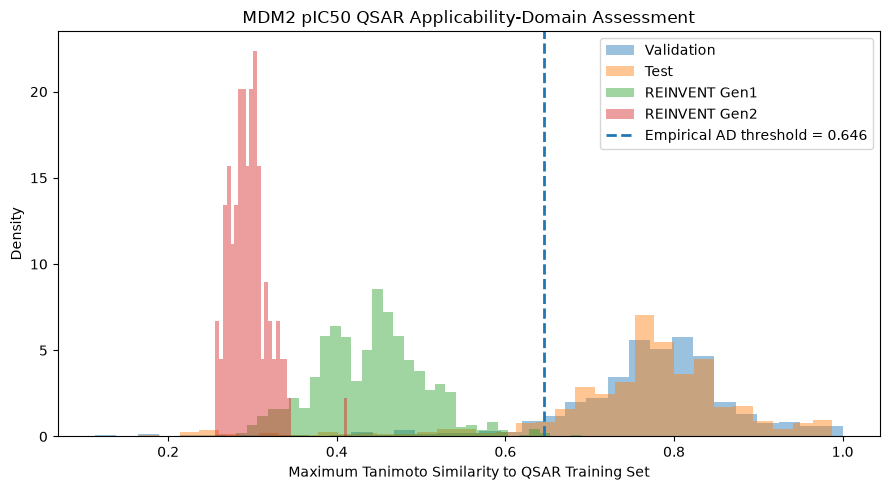

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.hist(
    val_df["Nearest_Train_Similarity"].dropna(),
    bins=35,
    alpha=0.45,
    density=True,
    label="Validation"
)

plt.hist(
    test_df["Nearest_Train_Similarity"].dropna(),
    bins=35,
    alpha=0.45,
    density=True,
    label="Test"
)

plt.hist(
    gen1_df["Nearest_Train_Similarity"].dropna(),
    bins=35,
    alpha=0.45,
    density=True,
    label="REINVENT Gen1"
)

plt.hist(
    gen2_df["Nearest_Train_Similarity"].dropna(),
    bins=35,
    alpha=0.45,
    density=True,
    label="REINVENT Gen2"
)

plt.axvline(
    AD_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label=f"Empirical AD threshold = {AD_THRESHOLD:.3f}"
)

plt.xlabel("Maximum Tanimoto Similarity to QSAR Training Set")
plt.ylabel("Density")
plt.title("MDM2 pIC50 QSAR Applicability-Domain Assessment")

plt.legend()
plt.tight_layout()
plt.show()

### AD.9 — Add DiffSBDD to the Cross-Workflow Applicability-Domain Comparison

In [10]:
from pathlib import Path
import pandas as pd

DIFFSBDD_CSV = Path(
    "/Users/maryta/Desktop/MDM2_diffusion_final/"
    "outputs/generated/5ZXF_diffsbdd_2863_pic50_predictions.csv"
)

diffsbdd_ad_df = pd.read_csv(DIFFSBDD_CSV)

print("DiffSBDD molecules:", len(diffsbdd_ad_df))

diffsbdd_ad_df["Nearest_Train_Similarity"] = (
    diffsbdd_ad_df["SMILES"]
    .apply(nearest_train_similarity)
)

diffsbdd_ad_df["AD_Supported"] = (
    diffsbdd_ad_df["Nearest_Train_Similarity"] >= AD_THRESHOLD
)

print(
    diffsbdd_ad_df["Nearest_Train_Similarity"]
    .describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

print(
    "\nDiffSBDD above threshold:",
    int(diffsbdd_ad_df["AD_Supported"].sum())
)

print(
    "Percent supported:",
    100 * diffsbdd_ad_df["AD_Supported"].mean()
)

DiffSBDD molecules: 2863
count    2863.000000
mean        0.186872
std         0.041445
min         0.075000
10%         0.138614
25%         0.158375
50%         0.181818
75%         0.211111
90%         0.241758
95%         0.262113
max         0.372093
Name: Nearest_Train_Similarity, dtype: float64

DiffSBDD above threshold: 0
Percent supported: 0.0


### AD.10 — Final Cross-Workflow Applicability-Domain Comparison

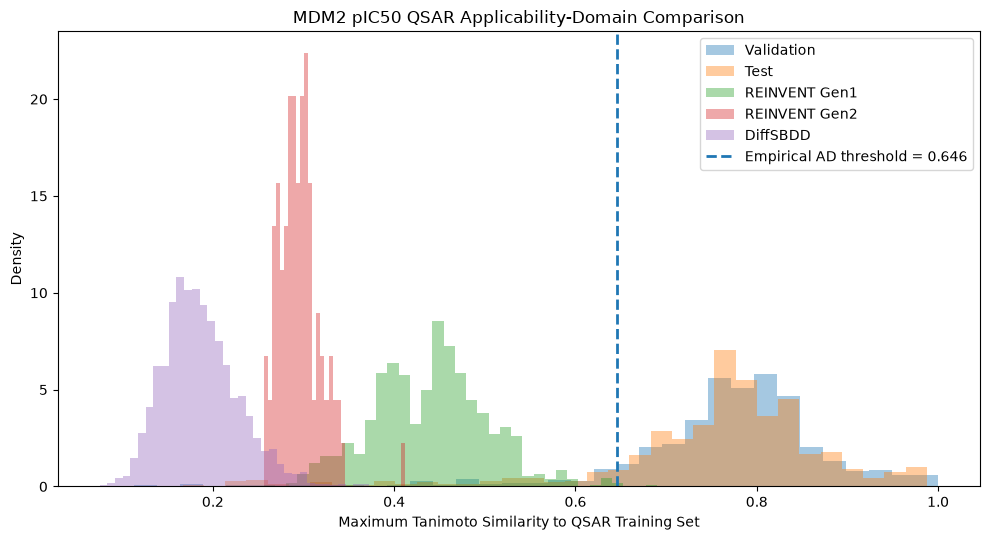

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5.5))

plt.hist(
    val_df["Nearest_Train_Similarity"].dropna(),
    bins=35,
    alpha=0.40,
    density=True,
    label="Validation"
)

plt.hist(
    test_df["Nearest_Train_Similarity"].dropna(),
    bins=35,
    alpha=0.40,
    density=True,
    label="Test"
)

plt.hist(
    gen1_df["Nearest_Train_Similarity"].dropna(),
    bins=35,
    alpha=0.40,
    density=True,
    label="REINVENT Gen1"
)

plt.hist(
    gen2_df["Nearest_Train_Similarity"].dropna(),
    bins=35,
    alpha=0.40,
    density=True,
    label="REINVENT Gen2"
)

plt.hist(
    diffsbdd_ad_df["Nearest_Train_Similarity"].dropna(),
    bins=35,
    alpha=0.40,
    density=True,
    label="DiffSBDD"
)

plt.axvline(
    AD_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label=f"Empirical AD threshold = {AD_THRESHOLD:.3f}"
)

plt.xlabel("Maximum Tanimoto Similarity to QSAR Training Set")
plt.ylabel("Density")
plt.title("MDM2 pIC50 QSAR Applicability-Domain Comparison")

plt.legend()
plt.tight_layout()

plt.show()

### Interpretation

The held-out validation and test compounds show substantially higher
nearest-training-set similarity than all three generated molecular sets.
Using the 10th percentile of the combined validation and test similarity
distribution as an empirical applicability-domain threshold
(Tanimoto similarity = 0.646), only 3 of 870 REINVENT Generation 1
molecules (0.34%) were above the threshold, whereas no REINVENT
Generation 2 or DiffSBDD molecules were above the threshold.

The median nearest-training similarity decreased from REINVENT Generation 1
(0.443) to Generation 2 (0.294) and DiffSBDD (0.182), indicating progressive
exploration of chemical space increasingly distant from the original MDM2
QSAR training set.

Accordingly, predicted pIC50 values for generated compounds, particularly
REINVENT Generation 2 and DiffSBDD molecules, should be interpreted as
extrapolative predictions rather than as similarity-supported QSAR estimates.

In [1]:
from pathlib import Path

ROOT = Path("/Users/maryta/Downloads/mdm2_Reinvent_4_final")

for p in ROOT.rglob("*"):
    if p.is_file() and "nutlin" in p.name.lower() and "vina" in p.name.lower():
        print(p)
        

In [3]:
from pathlib import Path

ROOT = Path("/Users/maryta/Downloads/mdm2_Reinvent_4_final")

# Find ANY file/folder containing Nutlin
matches = []

for p in ROOT.rglob("*"):
    if "nutlin" in p.name.lower():
        matches.append(p)

print("Found:", len(matches))

for p in matches:
    print(p)

Found: 48
/Users/maryta/Downloads/mdm2_Reinvent_4_final/Gen2_Candidate_3_vs_Nutlin3a_clean.png
/Users/maryta/Downloads/mdm2_Reinvent_4_final/Gen2_Candidate_3_vs_Nutlin3a.png
/Users/maryta/Downloads/mdm2_Reinvent_4_final/docking/complexes/Nutlin_3a_complex.pdb
/Users/maryta/Downloads/mdm2_Reinvent_4_final/docking/plip/Nutlin_3a
/Users/maryta/Downloads/mdm2_Reinvent_4_final/docking/plip/Nutlin_3a/Nutlin_3a_complex_protonated.pdb
/Users/maryta/Downloads/mdm2_Reinvent_4_final/docking/plip/Nutlin_3a/Nutlin_3a_complex_report.txt
/Users/maryta/Downloads/mdm2_Reinvent_4_final/docking/plip/Nutlin_3a/Nutlin_3a_complex_report.xml
/Users/maryta/Downloads/mdm2_Reinvent_4_final/docking/generation2/results/candidate4_vs_nutlin3a_summary.csv
/Users/maryta/Downloads/mdm2_Reinvent_4_final/REINVENT4/sampling_nutlin3a_100.toml
/Users/maryta/Downloads/mdm2_Reinvent_4_final/REINVENT4/output/nutlin3a_top_ranked_grid.png
/Users/maryta/Downloads/mdm2_Reinvent_4_final/REINVENT4/output/nutlin3a_generated_with_pr

In [4]:
from pathlib import Path

ROOT = Path("/Users/maryta/Downloads/mdm2_Reinvent_4_final")


hits = []

for p in ROOT.rglob("*"):
    if p.is_file() and p.suffix.lower() in [".log", ".txt", ".pdbqt", ".pdb", ".csv"]:
        try:
            text = p.read_text(errors="ignore")

            if "Nutlin_3a" in text or "Nutlin-3a" in text or "nutlin3a" in text.lower():
                if (
                    "REMARK VINA RESULT" in text
                    or "Affinity:" in text
                    or "kcal/mol" in text
                    or "-8.220" in text
                ):
                    hits.append(p)
        except:
            pass

print("Possible Nutlin docking-result files:", len(hits))

for p in hits:
    print(p)

Possible Nutlin docking-result files: 1
/Users/maryta/Downloads/mdm2_Reinvent_4_final/docking/generation2/results/candidate4_vs_nutlin3a_summary.csv


In [5]:
for p in ROOT.rglob("*"):
    if p.is_file():
        try:
            text = p.read_text(errors="ignore")

            if "-8.220" in text:
                print("\nFOUND -8.220 IN:")
                print(p)

                for line in text.splitlines():
                    if "-8.220" in line:
                        print(line)
        except:
            pass


FOUND -8.220 IN:
/Users/maryta/Downloads/mdm2_Reinvent_4_final/docs/generation_1/09_docking.md
| Nutlin-3a | -8.220 | 0.000 |

FOUND -8.220 IN:
/Users/maryta/Downloads/mdm2_Reinvent_4_final/docking/redocking_5ZXF_preserved/NUT_redocked_preserved.pdbqt
REMARK VINA RESULT:    -8.220      0.000      0.000

FOUND -8.220 IN:
/Users/maryta/Downloads/mdm2_Reinvent_4_final/docking/generation2/complexes/Gen2_Gated_Candidate_2_complex.pdb
ATOM     35  C   UNL     1       2.846 -22.369  -8.220  1.00  0.00           C  

FOUND -8.220 IN:
/Users/maryta/Downloads/mdm2_Reinvent_4_final/docking/generation2/complexes/Gen2_Gated_Candidate_2_ligand.pdb
ATOM     35  C   UNL     1       2.846 -22.369  -8.220  1.00  0.00           C  

FOUND -8.220 IN:
/Users/maryta/Downloads/mdm2_Reinvent_4_final/docking/generation2/plip/Gen2_Gated_Candidate_2/Gen2_Gated_Candidate_2_complex_protonated.pdb
ATOM    756  C   UNL A   1       2.846 -22.369  -8.220  1.00  0.00           C  

FOUND -8.220 IN:
/Users/maryta/Downl

Yes. Now that **Nutlin-3a Vina = −8.220 kcal/mol** is verified from the 5ZXF redocking output, the updated table is:

| Method            | Candidate          | Vina (kcal/mol) ↓ | Pred. pIC50* ↑ |     QED ↑ | Bioavailability ↑ |    hERG ↓ |    DILI ↓ |    P-gp ↓ | Hydrophobic | H-bonds | Salt bridges |
| ----------------- | ------------------ | ----------------: | -------------: | --------: | ----------------: | --------: | --------: | --------: | ----------: | ------: | -----------: |
| **Reference**     | **Nutlin-3a**      |        **−8.220** |          6.707 |     0.394 |             0.814 |     0.844 |     0.971 |     0.977 |           — |       — |            — |
| REINVENT Gen1     | Candidate 1        |            −7.719 |          7.053 |     0.403 |             0.899 |     0.943 |     0.933 |     0.968 |           — |       — |            — |
| REINVENT Gen1     | Candidate 4        |            −6.706 |          6.852 |     0.413 |             0.823 |     0.634 |     0.876 |     0.329 |           — |       — |            — |
| REINVENT Gen1     | Candidate 5        |            −7.328 |          6.806 |     0.455 |             0.821 |     0.907 |     0.936 |     0.952 |           — |       — |            — |
| REINVENT Gen2     | Candidate 1        |            −7.227 |          6.837 |     0.575 |             0.808 |     0.684 |     0.694 |     0.548 |           8 |       1 |            1 |
| REINVENT Gen2     | Candidate 2        |            −7.643 |          6.928 |     0.474 |             0.871 |     0.804 |     0.834 |     0.675 |           4 |       2 |            0 |
| **REINVENT Gen2** | **Candidate 3**    |        **−8.219** |      **7.070** | **0.619** |             0.734 |     0.846 | **0.518** |     0.662 |       **8** |       1 |            0 |
| DiffSBDD          | 5ZXF_DiffSBDD_0504 |            −6.135 |          5.801 |     0.707 |         **0.950** | **0.032** | **0.173** |     0.003 |           7 |       0 |            0 |
| DiffSBDD          | 5ZXF_DiffSBDD_2032 |            −5.494 |          6.043 |     0.696 |             0.923 |     0.040 |     0.314 | **0.002** |           0 |       0 |            0 |
| DiffSBDD          | 5ZXF_DiffSBDD_2654 |            −5.091 |          6.145 | **0.724** |             0.937 |     0.053 |     0.193 |     0.003 |           2 |       1 |            0 |

**↑ = higher is favorable; ↓ = lower/more negative is favorable.**

The key result is now particularly clear: **Gen2 Candidate 3 has a Vina score of −8.219 kcal/mol versus −8.220 kcal/mol for Nutlin-3a.** Treat these as essentially comparable docking scores, not as a meaningful 0.001 kcal/mol difference.

At the same time, Gen2 Candidate 3 improves QED from **0.394 → 0.619** and predicted DILI from **0.971 → 0.518**, although not every ADMET property improves. DiffSBDD gives the strongest predicted developability profiles but weaker docking scores.

* **Predicted pIC50 is used as a relative screening/prioritization signal, not as an experimentally validated activity measurement, particularly given the QSAR applicability-domain limitation.**


Yes. Now that **Nutlin-3a Vina = −8.220 kcal/mol** is verified from the 5ZXF redocking output, the updated table is:

| Method            | Candidate          | Vina (kcal/mol) ↓ | Pred. pIC50* ↑ |     QED ↑ | Bioavailability ↑ |    hERG ↓ |    DILI ↓ |    P-gp ↓ | Hydrophobic | H-bonds | Salt bridges |
| ----------------- | ------------------ | ----------------: | -------------: | --------: | ----------------: | --------: | --------: | --------: | ----------: | ------: | -----------: |
| **Reference**     | **Nutlin-3a**      |        **−8.220** |          6.707 |     0.394 |             0.814 |     0.844 |     0.971 |     0.977 |           — |       — |            — |
| REINVENT Gen1     | Candidate 1        |            −7.719 |          7.053 |     0.403 |             0.899 |     0.943 |     0.933 |     0.968 |           — |       — |            — |
| REINVENT Gen1     | Candidate 4        |            −6.706 |          6.852 |     0.413 |             0.823 |     0.634 |     0.876 |     0.329 |           — |       — |            — |
| REINVENT Gen1     | Candidate 5        |            −7.328 |          6.806 |     0.455 |             0.821 |     0.907 |     0.936 |     0.952 |           — |       — |            — |
| REINVENT Gen2     | Candidate 1        |            −7.227 |          6.837 |     0.575 |             0.808 |     0.684 |     0.694 |     0.548 |           8 |       1 |            1 |
| REINVENT Gen2     | Candidate 2        |            −7.643 |          6.928 |     0.474 |             0.871 |     0.804 |     0.834 |     0.675 |           4 |       2 |            0 |
| **REINVENT Gen2** | **Candidate 3**    |        **−8.219** |      **7.070** | **0.619** |             0.734 |     0.846 | **0.518** |     0.662 |       **8** |       1 |            0 |
| DiffSBDD          | 5ZXF_DiffSBDD_0504 |            −6.135 |          5.801 |     0.707 |         **0.950** | **0.032** | **0.173** |     0.003 |           7 |       0 |            0 |
| DiffSBDD          | 5ZXF_DiffSBDD_2032 |            −5.494 |          6.043 |     0.696 |             0.923 |     0.040 |     0.314 | **0.002** |           0 |       0 |            0 |
| DiffSBDD          | 5ZXF_DiffSBDD_2654 |            −5.091 |          6.145 | **0.724** |             0.937 |     0.053 |     0.193 |     0.003 |           2 |       1 |            0 |

**↑ = higher is favorable; ↓ = lower/more negative is favorable.**

The key result is now particularly clear: **Gen2 Candidate 3 has a Vina score of −8.219 kcal/mol versus −8.220 kcal/mol for Nutlin-3a.** Treat these as essentially comparable docking scores, not as a meaningful 0.001 kcal/mol difference.

At the same time, Gen2 Candidate 3 improves QED from **0.394 → 0.619** and predicted DILI from **0.971 → 0.518**, although not every ADMET property improves. DiffSBDD gives the strongest predicted developability profiles but weaker docking scores.

* **Predicted pIC50 is used as a relative screening/prioritization signal, not as an experimentally validated activity measurement, particularly given the QSAR applicability-domain limitation.**




REINVENT Gen2 produced the strongest overall MDM2-binding candidate. Candidate 3 had a Vina score of −8.219 kcal/mol, essentially the same as Nutlin-3a at −8.220, while also improving QED and predicted DILI.

DiffSBDD produced the best developability-oriented profiles. Its top molecules had higher QED and much lower predicted hERG, DILI, and P-gp liabilities, but their docking scores were clearly weaker, around −5.1 to −6.1 kcal/mol.

So for your project question, I would say:

REINVENT Gen2 produced the most balanced candidate overall, while DiffSBDD produced candidates with better predicted developability but weaker predicted MDM2 binding.

Hi George, I was also thinking about a possible third option for addressing the applicability-domain issue, and I wanted to get your opinion on whether it would be methodologically reasonable.

Rather than removing the pIC50 predictor from the reward entirely, we could make its contribution dependent on how well a generated molecule is supported by the QSAR model's applicability domain.

The idea would be to introduce an applicability-domain-aware reward. For each generated molecule, we could calculate its maximum similarity to the QSAR training set, as we did in the AD analysis. If the molecule remains well within the supported chemical space, the predicted pIC50 would retain its normal contribution to the reward. As the molecule moves further away from the training chemistry, the contribution of predicted pIC50 would progressively decrease. Molecules substantially outside the applicability domain could additionally receive a penalty.

Conceptually, this would be something like:

effective potency contribution = pIC50 score × AD-support factor

rather than treating the pIC50 prediction as equally reliable for every generated molecule.

I think this could be preferable to simply lowering the global pIC50 weight, because the problem is not necessarily that the QSAR model is uninformative. The issue is that its predictions become less well supported as the generator moves into more distant chemical space. An AD-aware term would therefore reduce the influence of the predictor specifically where extrapolation becomes stronger, while still allowing REINVENT to explore new chemistry.

We could implement this either as a continuous penalty/weighting function or as a simpler threshold-based rule. I would probably favor the continuous version so that we do not impose an arbitrary hard boundary on chemical-space exploration.

This would, of course, represent a revised reward and therefore a new experiment rather than a correction to the existing Gen1/Gen2 results. Do you think this would be worth testing as an additional generation, or would you still prefer keeping the current results and discussing the AD issue as a limitation?